### Table from paper on duration vs transmissability
https://www.nature.com/articles/s41586-023-06952-2#Sec10

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/duration_data_from_paper.csv')
df.head()

,binDuration,binAvgRiskScorePerHour,n,probability_of_reported_transmission,lowerCI,upperCI
0,0-0.5,1.1-1.3,592980,0.001891,0.001783,0.002006
1,0-0.5,1.3-1.6,731605,0.001929,0.001829,0.002032
2,0-0.5,1.6-1.8,525992,0.002047,0.001927,0.002173
3,0-0.5,1.8-2.2,691000,0.002213,0.002103,0.002326
4,0-0.5,2.2-3.3,676457,0.002354,0.002239,0.002472


[np.float64(0.0021573673765309595), np.float64(0.006878620143983938), np.float64(0.01663502355345293), np.float64(0.024308541347464574), np.float64(0.040352978957641644), np.float64(0.12288538755708409)]


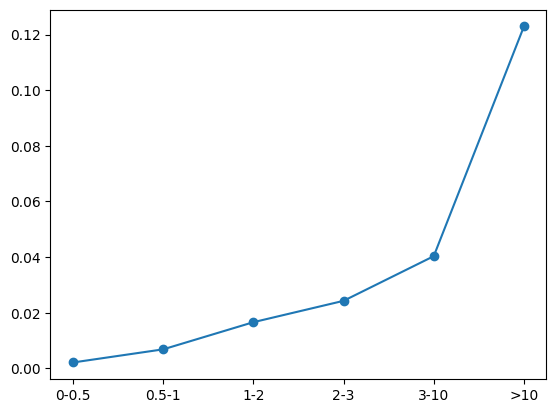

In [10]:
keys = df['binDuration'].unique()
xs, ys = [], []
for key in keys:
    df_tmp = df[df['binDuration'] == key]
    xs.append(key)
    ys.append(sum([df_tmp['probability_of_reported_transmission'].iloc[i] * df_tmp['n'].iloc[i] for i in range(len(df_tmp))]) / sum(df_tmp['n']))
plt.plot(xs, ys, marker='o')
print(ys)

Best-fit beta: 0.00015328166356882712
Best-fit alpha: 0.6939744381223635


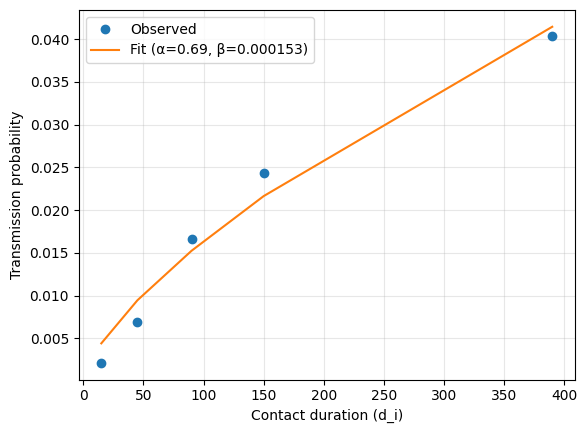

In [ ]:
from scipy.optimize import least_squares

# Model transmission probability
def P_model(beta, gamma, d, alpha):
    beta_i = beta * (d ** alpha)
    lam = beta_i + gamma
    return (beta_i / lam) * (1.0 - np.exp(-lam / gamma))

# Objective for least-squares fitting
def residuals(params, d, P_obs, gamma, fix_beta=False):
    if fix_beta:
        alpha = params[0]
        beta = FIXED_BETA   # define elsewhere if known
    else:
        beta, alpha = params
    P_pred = P_model(beta, gamma, d, alpha)
    return P_pred - P_obs

# Example data (replace with your own)
d_data = np.array([0.25, 0.75, 1.5, 2.5, 6.5])*60  # your 5 duration scales
P_obs  = np.array([0.0021573673765309595, 0.006878620143983938, 0.01663502355345293, 0.024308541347464574, 0.040352978957641644])  # empirical probs
gamma = 1/7  # example: recovery rate per day

# Fit both beta and alpha
x0 = [0.1, 1.0]  # initial guesses for [beta, alpha]
result = least_squares(residuals, x0, args=(d_data, P_obs, gamma))
beta_hat, alpha_hat = result.x

print("Best-fit beta:", beta_hat)
print("Best-fit alpha:", alpha_hat)


P_fit = P_model(beta_hat, gamma, d_data, alpha_hat)

plt.plot(d_data, P_obs, 'o', label='Observed')
plt.plot(d_data, P_fit, '-', label=f'Fit (α={alpha_hat:.2f}, β={beta_hat:.3g})')
plt.xlabel('Contact duration (d_i)')
plt.ylabel('Transmission probability')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Duration Scaling Final Size Plots

/home/lmurraykearney/anaconda3/envs/phd2/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/lmurraykearney/anaconda3/envs/phd2/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


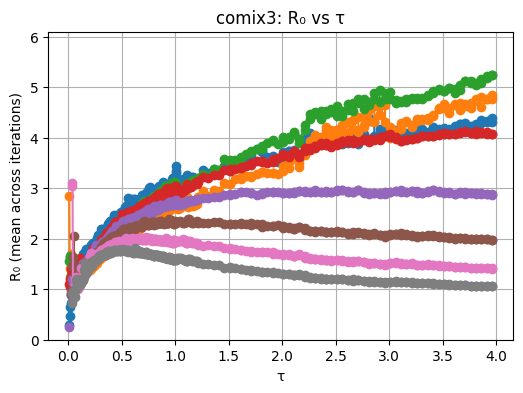

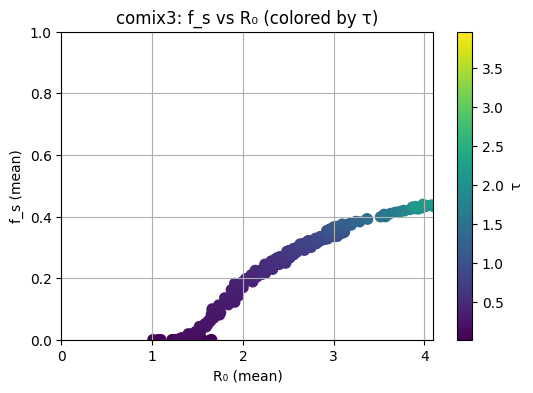

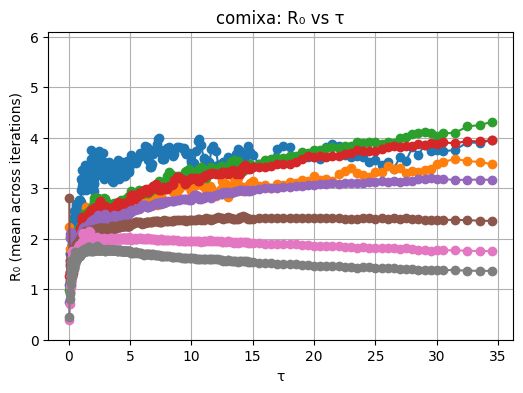

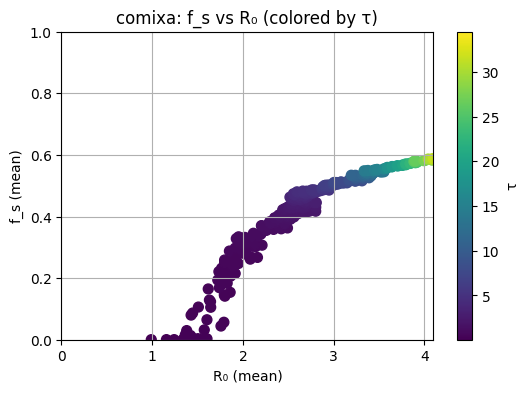

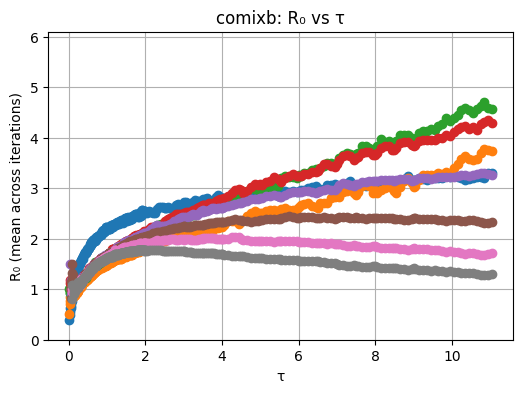

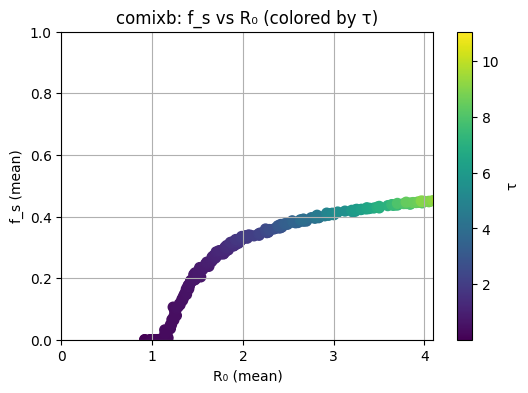

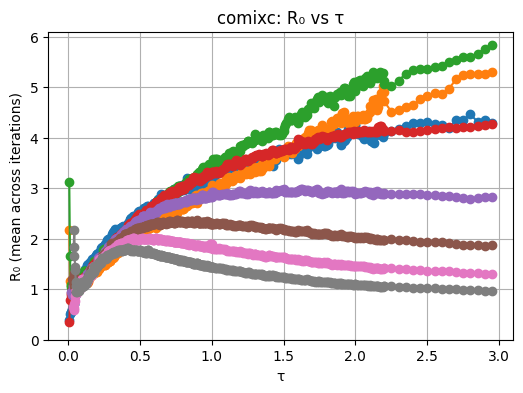

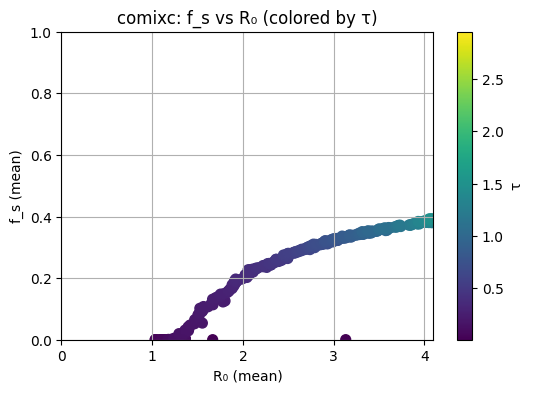

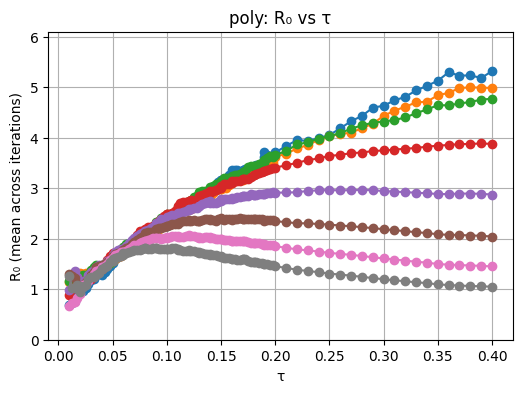

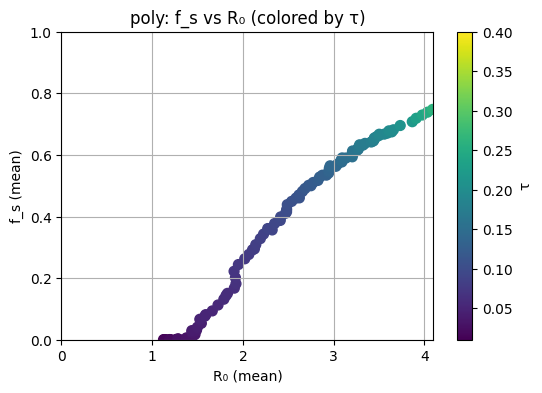

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict
from scipy import stats

datas = ['comix3','comixa','comixb','comixc','poly']
n=100_000

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-5 mins', '5-15 mins', '15-60 mins', '1-4 hours', '4+ hours']

compare = {}
num_network = 260
for data in datas:
    res = {'taus': [], 'fs': [], 'r0': [], 'r02': [], 'r03': [], 'r04': [], 'r05': [], 'r06': [], 'r07': [], 'r08': []}
    for k in range(num_network):
        try:
            with open(f'seir_sims/{data}_{k}.json', 'r') as f:
                res_tmp = json.load(f)
            # res['age_dur_sc'] = res_tmp['age_dur_sc']

            for tau, fs_row, r0_row, r02_row, r03_row, r04_row, r05_row, r06_row, r07_row, r08_row in zip(res_tmp["taus"], res_tmp["fs"], res_tmp["r0"], res_tmp['r02'], res_tmp['r03'], res_tmp['r04'], res_tmp['r05'], res_tmp['r06'], res_tmp['r07'], res_tmp['r08']):
                if tau not in res["taus"]:
                    res["taus"].append(tau)
                    res["fs"].append(fs_row)
                    res["r0"].append(r0_row)
                    res["r02"].append(r02_row)
                    res["r03"].append(r03_row)
                    res["r04"].append(r04_row)
                    res["r05"].append(r05_row)
                    res["r06"].append(r06_row)
                    res["r07"].append(r07_row)
                    res["r08"].append(r08_row)
                else:
                    idx = res["taus"].index(tau)
                    for fs, r0, r02, r03, r04, r05, r06, r07, r08 in zip(fs_row, r0_row, r02_row, r03_row, r04_row, r05_row, r06_row, r07_row, r08_row):
                        res["fs"][idx].append(fs)
                        res["r0"][idx].append(r0)
                        res["r02"][idx].append(r02)
                        res["r03"][idx].append(r03)
                        res["r04"][idx].append(r04)
                        res["r05"][idx].append(r05)
                        res["r06"][idx].append(r06)
                        res["r07"][idx].append(r07)
                        res["r08"][idx].append(r08)
        except:
            a=1
            
    taus = res["taus"]
    r0 = res["r0"]          
    r02 = res["r02"]           
    r03 = res["r03"] 
    r04 = res["r04"]
    r05 = res["r05"]
    r06 = res["r06"]
    r07 = res["r07"]
    r08 = res["r08"]         
    # tmp = res["age_dur_sc"]
    fs = res['fs']
    
    sorted_data = sorted(zip(taus, fs, r0, r02, r03, r04, r05, r06, r07, r08), key=lambda x: x[0])
    taus, fs, r0, r02, r03, r04, r05, r06, r07, r08 = map(list, zip(*sorted_data))

    r0_mean = [np.mean([b for b in a if b>0]) for a in r0]
    r02_mean = [np.mean([b for b in a if b>0]) for a in r02]
    r03_mean = [np.mean([b for b in a if b>0]) for a in r03]
    r04_mean = [np.mean([b for b in a if b>0]) for a in r04]
    r05_mean = [np.mean([b for b in a if b>0]) for a in r05]
    r06_mean = [np.mean([b for b in a if b>0]) for a in r06]
    r07_mean = [np.mean([b for b in a if b>0]) for a in r07]
    r08_mean = [np.mean([b for b in a if b>0]) for a in r08]
    fs_mean = [np.mean([b for b in a if b>0]) for a in fs]
    # tmp_a = {}
    # for i, t in enumerate(taus):
    #     tmp_a[t] = np.array([b for b in tmp[i] if len(b)>0])
    # keys = list(tmp_a.keys())
    # keys.sort()
    # dur_breakdown = []
    # for key in keys:
    #     # print(key, np.mean([[sum(b) for b in a] for a in tmp_a[key]], axis=0).shape)
    #     if len(tmp_a[key]) > 0:
    #         dur_breakdown.append(np.median([[sum(b) for b in a] for a in tmp_a[key]], axis=0))

    # 1) R0 vs taus
    r0_mean = [a if idx in [0,len(r0_mean)] else np.mean(r0_mean[idx-1:idx+2]) for idx, a in enumerate(r0_mean)]
    r02_mean = [a if idx in [0,len(r02_mean)] else np.mean(r02_mean[idx-1:idx+2]) for idx, a in enumerate(r02_mean)]
    r03_mean = [a if idx in [0,len(r03_mean)] else np.mean(r03_mean[idx-1:idx+2]) for idx, a in enumerate(r03_mean)]
    r04_mean = [a if idx in [0,len(r04_mean)] else np.mean(r04_mean[idx-1:idx+2]) for idx, a in enumerate(r04_mean)]
    r05_mean = [a if idx in [0,len(r05_mean)] else np.mean(r05_mean[idx-1:idx+2]) for idx, a in enumerate(r05_mean)]
    r06_mean = [a if idx in [0,len(r06_mean)] else np.mean(r06_mean[idx-1:idx+2]) for idx, a in enumerate(r06_mean)]
    r07_mean = [a if idx in [0,len(r07_mean)] else np.mean(r07_mean[idx-1:idx+2]) for idx, a in enumerate(r07_mean)]
    r08_mean = [a if idx in [0,len(r08_mean)] else np.mean(r08_mean[idx-1:idx+2]) for idx, a in enumerate(r08_mean)]
    plt.figure(figsize=(6,4))
    plt.plot(taus, r0_mean, marker='o', label="R₀ 1")
    plt.plot(taus, r02_mean, marker='o', label="R₀ 2")
    plt.plot(taus, r03_mean, marker='o', label="R₀ 3")
    plt.plot(taus, r04_mean, marker='o', label="R₀ 4")
    plt.plot(taus, r05_mean, marker='o', label="R₀ 5")
    plt.plot(taus, r06_mean, marker='o', label="R₀ 6")
    plt.plot(taus, r07_mean, marker='o', label="R₀ 7")
    plt.plot(taus, r08_mean, marker='o', label="R₀ 8")
    

    plt.xlabel("τ")
    plt.ylabel("R₀ (mean across iterations)")
    plt.title(f"{data}: R₀ vs τ")
    plt.ylim(0, 6.1)
    # plt.legend()
    plt.grid(True)
    plt.savefig(f'figs/sim_out/{data}_tau_vs_r0.png')
    plt.show()
    # plt.close()
    
    # new_age = np.zeros((9, 5, len(dur_breakdown)))
    # for i, _ in enumerate(dur_breakdown):
    #     for j in range(9):
    #         for k in range(5):
    #             # print(i, j, k, len(dur_breakdown), len(dur_breakdown[i]), len(dur_breakdown[i][j]))
    #             new_age[j][k][i] = dur_breakdown[i][j][k]
    # for age, tmp in enumerate(new_age):
    #     plt.figure(figsize=(6,4))
    #     for j in range(5):
    #         plt.plot(range(len(tmp[j])), [a/sum([b[idx] for b in tmp]) for idx, a in enumerate(tmp[j])], marker='o', label=f"{duration_labels[j]}")
    #     plt.xlabel(r"$\beta$")
    #     plt.ylabel("mean cases")
    #     plt.title(f"{data}: {bucket_labels[age]}")
    #     plt.ylim(0, 1)
    #     # plt.legend()
    #     plt.grid(True)
    #     plt.show()
    #     plt.close()

    # 3) fs vs R0
    plt.figure(figsize=(6,4))
    plt.scatter(r03_mean, fs_mean, c=taus, cmap="viridis", s=50)
    plt.colorbar(label="τ")
    plt.xlabel("R₀ (mean)")
    plt.ylabel("f_s (mean)")
    plt.title(f"{data}: f_s vs R₀ (colored by τ)")
    plt.xlim(0, 4.1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.savefig(f'figs/sim_out/{data}_fs_vs_r0.png')
    plt.show()
    # plt.close()
    
    # r0_mean = [np.mean([b for b in a if b>0]) for a in r0 if len(a) > 5]
    # r02_mean = [np.mean([b for b in a if b>0]) for a in r02 if len(a) > 5]
    # r03_mean = [np.mean([b for b in a if b>0]) for a in r03 if len(a) > 5]
    r0_mean = [[b for b in a if b>0] for a in r0 if len(a) > 5]
    r02_mean = [[b for b in a if b>0] for a in r02 if len(a) > 5]
    r03_mean = [[b for b in a if b>0] for a in r03 if len(a) > 5]
    fs_mean = [[b for b in a if b>0] for a in fs if len(a) > 5]
    taus = [a for i, a in enumerate(taus) if len(r0[i]) > 5]
    compare[data] = (taus, r0_mean, r02_mean, r03_mean, fs_mean)
    

    
# from scipy.optimize import fsolve

# # Function to solve final size equation for a given R0
# def final_size(R0):
#     # Define the function f(Z) = Z - (1 - exp(-R0 * Z)) = 0
#     func = lambda Z: Z - (1 - np.exp(-R0 * Z))
#     # Initial guess for Z
#     Z0_guess = 0.5
#     # Solve numerically
#     Z_solution, = fsolve(func, Z0_guess)
#     return Z_solution

# def final_size_array(R0_array):
#     return np.array([final_size(R0) for R0 in R0_array])
# R0_vals = np.linspace(0.1, 5, 100)
# Z_vals = final_size_array(R0_vals)

# fig, axs = plt.subplots(3,1,figsize=(8,18))
# for idx, ax in enumerate(axs):
#     ax.plot(R0_vals, Z_vals, 'k', label=r'$R_\infty$')

#     bin_edges = np.arange(0, 4.1, 0.1)  # bins: [0.0–0.1), [0.1–0.2), ..., [3.9–4.0]
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#     for data in datas:
#         taus, r0_mean, r02_mean, r03_mean, fs_mean = compare[data]
#         r0_mean = np.asarray(r0_mean)
#         r02_mean = np.asarray(r02_mean)
#         r03_mean = np.asarray(r03_mean)
#         fs_mean = np.asarray(fs_mean)

#         mean_per_bin = []
#         ci_lower = []
#         ci_upper = []

#         # Iterate over bins
#         for i in range(len(bin_edges) - 1):
#             # Find indices where r0_mean is within the bin
#             mask = ((r0_mean if idx == 0 else r02_mean if idx == 1 else r03_mean) >= bin_edges[i]) & ((r0_mean if idx == 0 else r02_mean if idx == 1 else r03_mean) < bin_edges[i+1])
#             fs_bin = fs_mean[mask]

#             if len(fs_bin) > 0:
#                 m = np.mean(fs_bin)
#                 # 95% confidence interval (t-distribution)
#                 ci = stats.t.interval(0.95, len(fs_bin)-1, loc=m, scale=stats.sem(fs_bin))
#                 mean_per_bin.append(m)
#                 ci_lower.append(m - ci[0])
#                 ci_upper.append(ci[1] - m)
#             else:
#                 mean_per_bin.append(np.nan)
#                 ci_lower.append(np.nan)
#                 ci_upper.append(np.nan)

#         # Plot mean with error bars (CI)
#         ax.errorbar(
#             bin_centers, mean_per_bin, 
#             yerr=[ci_lower, ci_upper],
#             fmt='o--', capsize=3, label=data
#         )

#     ax.set_xlabel("R₀ (mean)")
#     ax.set_ylabel("fₛ (mean)")
#     ax.set_xlim(0, 4)
#     ax.set_ylim(0, 1)
#     ax.grid(True)
#     ax.legend()
# plt.tight_layout()
# plt.show()

with open(f'seir_sims/together/fs.json', 'w') as f:
    json.dump(compare, f)

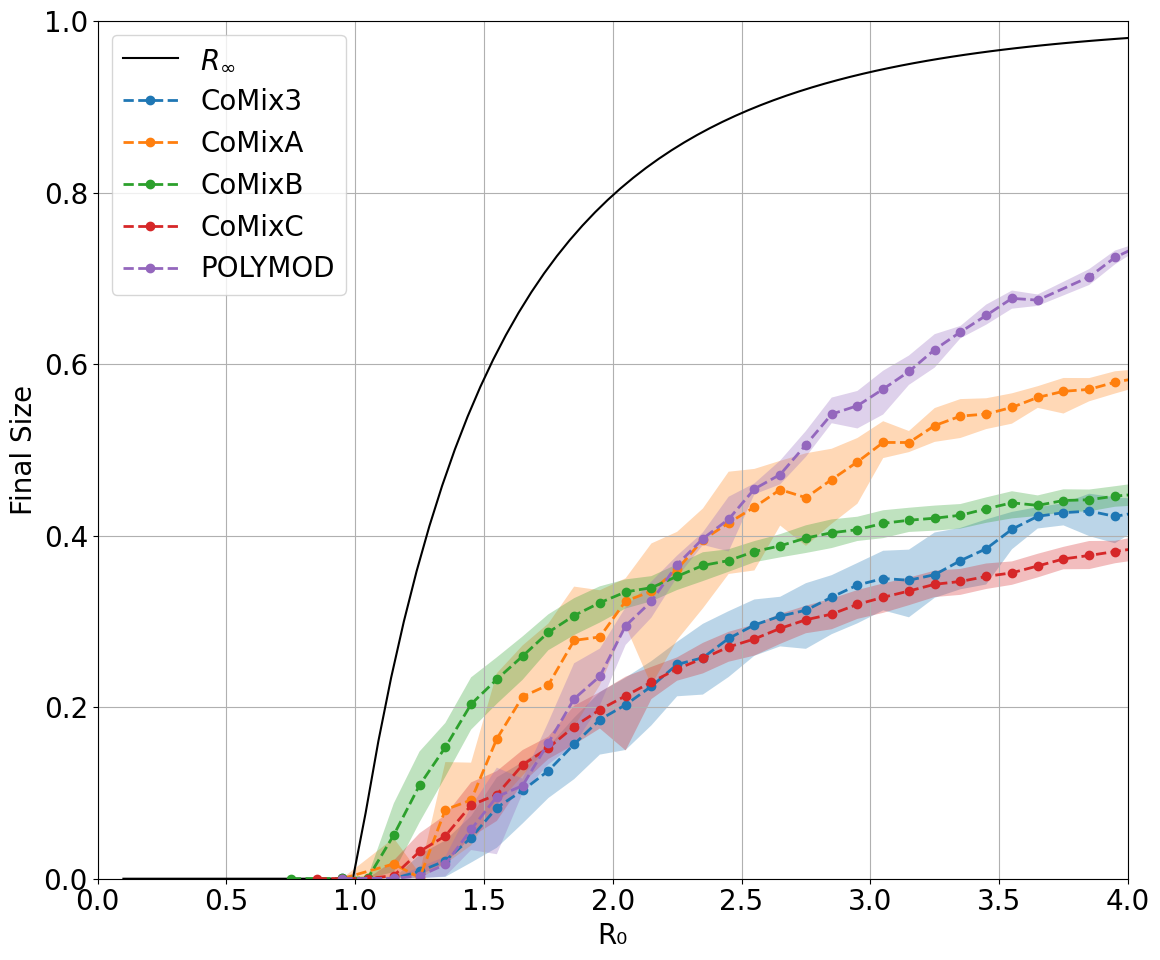

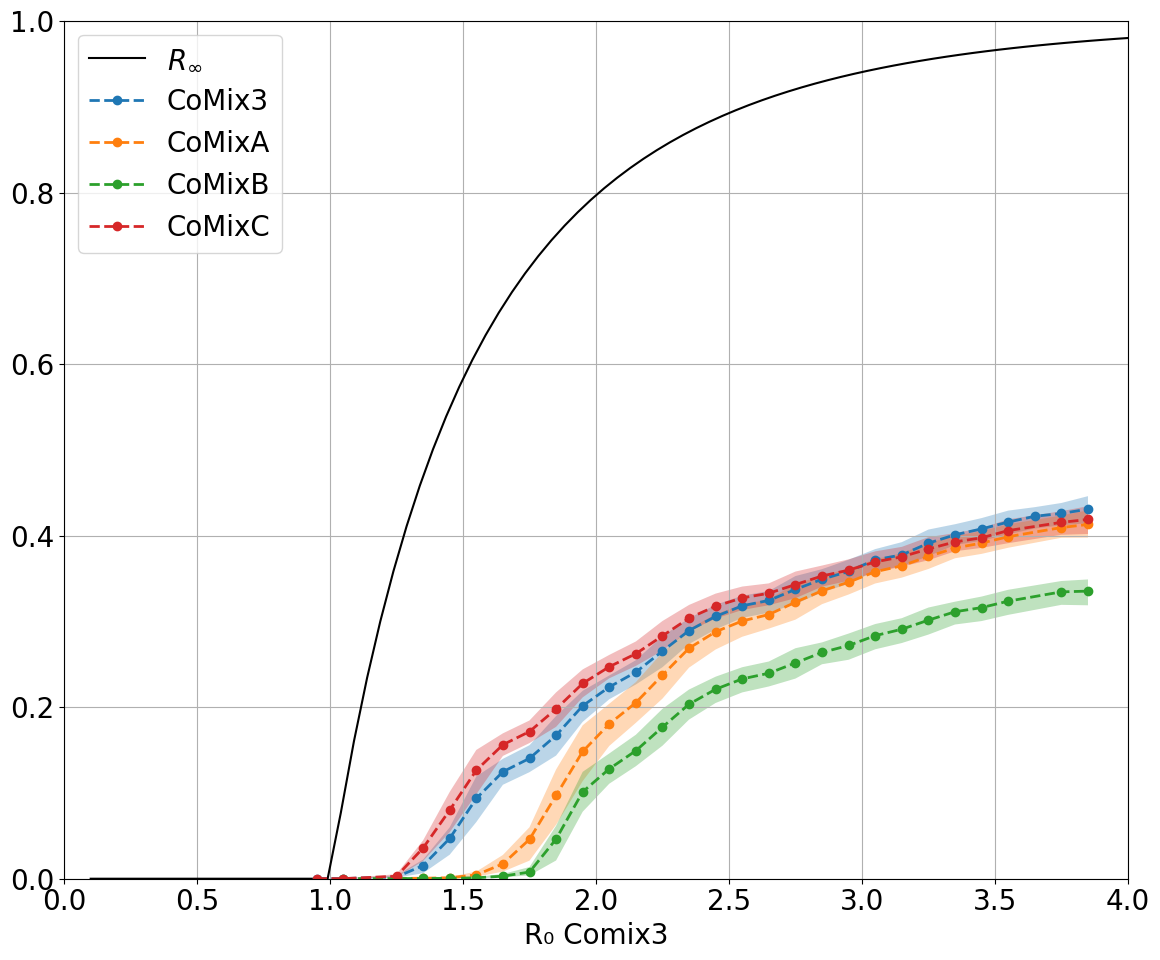

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.optimize import fsolve
from scipy import stats

def final_size(R0):
    func = lambda Z: Z - (1 - np.exp(-R0 * Z))
    Z0_guess = 0.5
    Z_solution, = fsolve(func, Z0_guess)
    return Z_solution

def final_size_array(R0_array):
    return np.array([final_size(R0) for R0 in R0_array])
R0_vals = np.linspace(0.1, 5, 100)
Z_vals = final_size_array(R0_vals)

plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(12,10))
plt.plot(R0_vals, Z_vals, 'k', label=r'$R_\infty$')

bin_edges = np.arange(0, 4.2, 0.1) 
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

data_names = ['CoMix3','CoMixA','CoMixB','CoMixC','POLYMOD']

with open(f'seir_sims/together/fs.json', 'r') as f:
    compare = json.load(f)

for key_idx, key in enumerate(compare.keys()):
    fs_vals = [[] for _ in bin_centers]
    taus, r0, r02, r03, fs = compare[key]
    r03_mean = [np.mean([b for b in a if b>0]) if len(a) > 0 else np.nan for a in r03]
    
    for tau_idx, tau_sim in enumerate([a for a in r03]):
        if len(tau_sim) > 0:
            for val_idx, _ in enumerate(tau_sim):
                for bin_idx in range(len(bin_edges) - 1):
                    if bin_edges[bin_idx] <= r03_mean[tau_idx] < bin_edges[bin_idx + 1]:
                        fs_vals[bin_idx].append(fs[tau_idx][val_idx])
                        break
    fs_mean = [np.mean(a) if len(a) > 0 else np.nan for a in fs_vals]
    ## remove what did not take off
    fs_vals = [[b for b in a if b > fs_mean[idx]/3] for idx, a in enumerate(fs_vals)]
    fs_mean = [np.mean(a) if len(a) > 0 else np.nan for a in fs_vals]
    ci_lower = [np.percentile(a, 5) if len(a) > 0 else np.nan for a in fs_vals]
    ci_upper = [np.percentile(a, 95) if len(a) > 0 else np.nan for a in fs_vals]
    
    bin_centers_tmp = bin_centers[~np.isnan(fs_mean)]
    fs_mean = np.array(fs_mean)[~np.isnan(fs_mean)]
    ci_lower = np.array(ci_lower)[~np.isnan(ci_lower)]
    ci_upper = np.array(ci_upper)[~np.isnan(ci_upper)]

    plt.plot(bin_centers_tmp, fs_mean, 'o--', label=data_names[key_idx], linewidth=2)
    plt.fill_between(bin_centers_tmp, ci_lower, ci_upper, alpha=0.3)
plt.xlabel("R₀")
plt.ylabel("Final Size")
plt.xlim(0, 4)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f'figs/sim_out/fs_vs_r0.pdf')
plt.show()


## use c3 as reference
# ref_keys = ['comix3', 'comixa', 'comixb', 'comixc']
ref_keys = ['comix3']
for ref_key in ref_keys:
    taus_ref, r0_ref, r02_ref, r03_ref, fs_ref = compare[ref_key]
    r03_mean_ref = [np.mean([b for b in a if b > 0]) for a in r03_ref if len(a) > 0]

    tau_bins = []
    for bc in bin_centers:
        idxs = [i for i, val in enumerate(r03_mean_ref)
                if bin_edges[np.argmin(np.abs(bin_centers - bc))] <= val < bin_edges[np.argmin(np.abs(bin_centers - bc)) + 1]]
        if len(idxs) > 0:
            tau_range = [np.min(np.array(taus_ref)[idxs]), np.max(np.array(taus_ref)[idxs])]
        else:
            tau_range = [np.nan, np.nan]
        tau_bins.append(tau_range)
        
    plt.figure(figsize=(12,10))
    plt.plot(R0_vals, Z_vals, 'k', label=r'$R_\infty$')

    for key_idx, key in enumerate(compare.keys()):
        if key == 'poly':
            continue
        taus, r0, r02, r03, fs = compare[key]
        fs_vals = [[] for _ in bin_centers]

        for tau_idx, tau_sim in enumerate([a for a in r03 if len(a) > 0]):
            tau_value = taus[tau_idx]
            for bin_idx, tau_range in enumerate(tau_bins):
                if np.isnan(tau_range[0]): 
                    continue
                if tau_range[0] <= tau_value <= tau_range[1]:
                    fs_vals[bin_idx].extend(fs[tau_idx])
                    break

        fs_mean = [np.mean(a) if len(a) > 0 else np.nan for a in fs_vals]
        fs_vals = [[b for b in a if b > fs_mean[idx]/2 and b < fs_mean[idx]*2] for idx, a in enumerate(fs_vals)]
        fs_mean = [np.mean(a) if len(a) > 0 else np.nan for a in fs_vals]
        ci_lower = [np.percentile(a, 5) if len(a) > 0 else np.nan for a in fs_vals]
        ci_upper = [np.percentile(a, 95) if len(a) > 0 else np.nan for a in fs_vals]

        bin_centers_tmp = bin_centers[~np.isnan(fs_mean)]
        fs_mean = np.array(fs_mean)[~np.isnan(fs_mean)]
        ci_lower = np.array(ci_lower)[~np.isnan(ci_lower)]
        ci_upper = np.array(ci_upper)[~np.isnan(ci_upper)]

        plt.plot(bin_centers_tmp, fs_mean, 'o--', label=data_names[key_idx], linewidth=2)
        plt.fill_between(bin_centers_tmp, ci_lower, ci_upper, alpha=0.3)

    # plt.title(f'{ref_key}')
    plt.xlabel("R₀ Comix3")
    # plt.ylabel("Final Size")
    plt.xlim(0, 4)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'figs/sim_out/fs_vs_r0_{ref_key}.pdf')
    plt.show()
    

# No scaling Final Size plots

/home/lmurraykearney/anaconda3/envs/phd2/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/lmurraykearney/anaconda3/envs/phd2/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


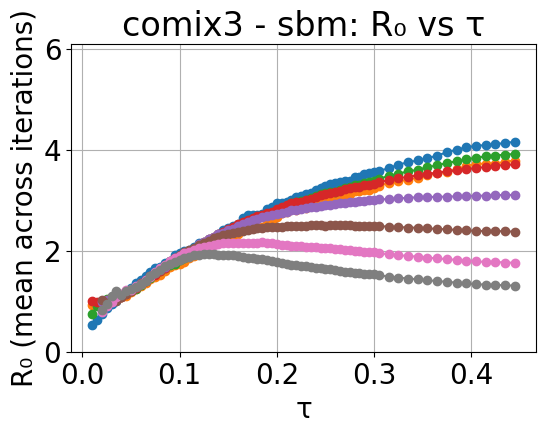

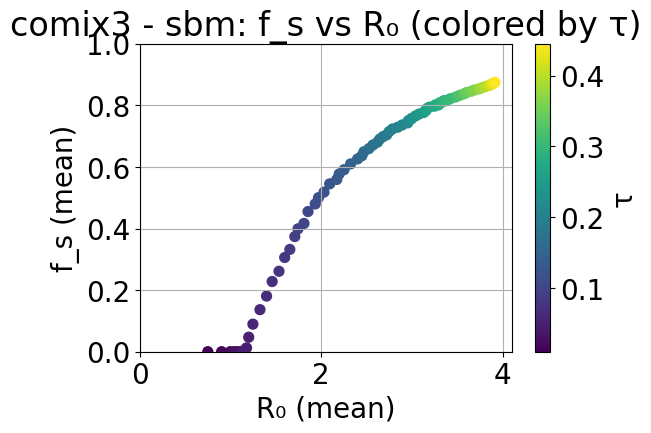

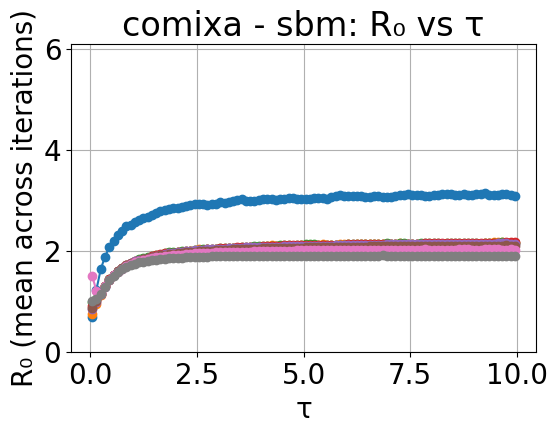

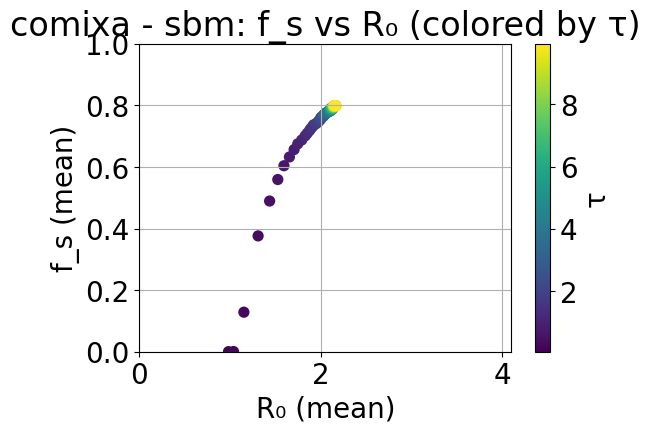

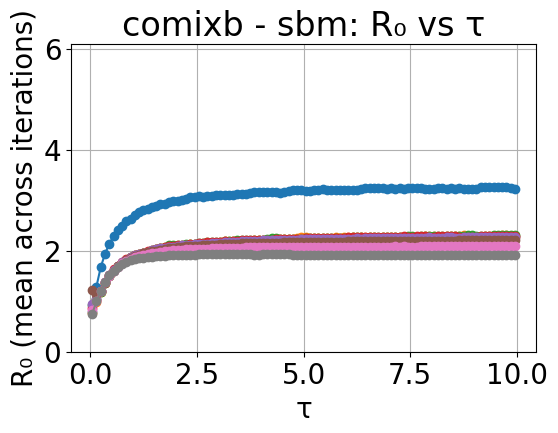

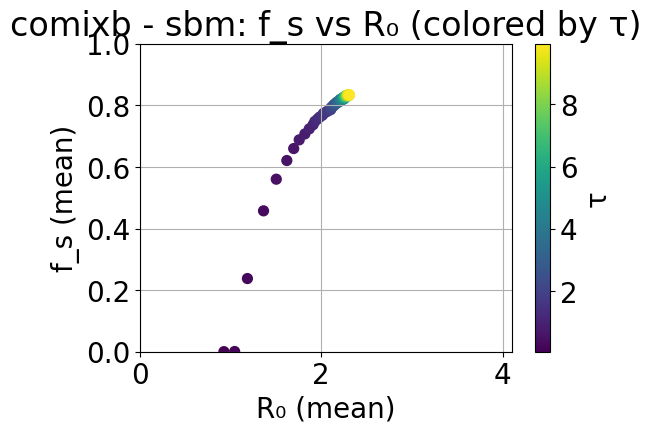

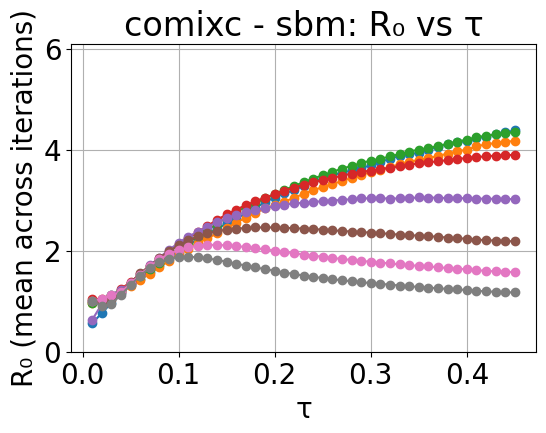

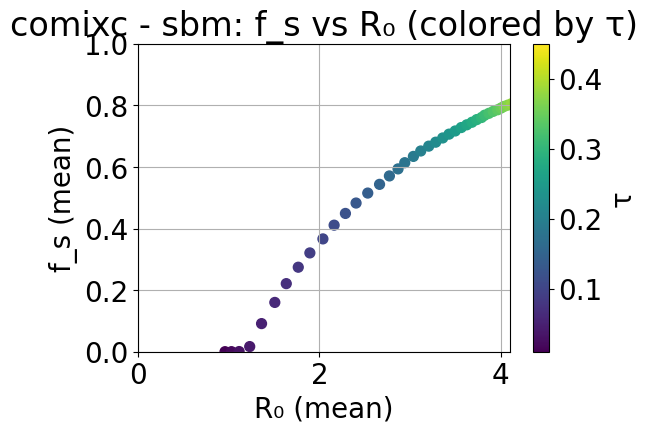

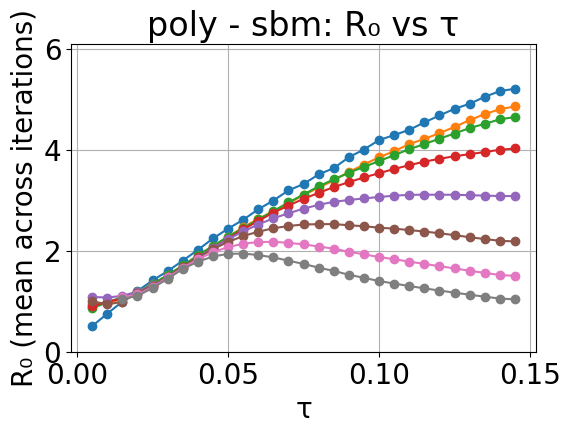

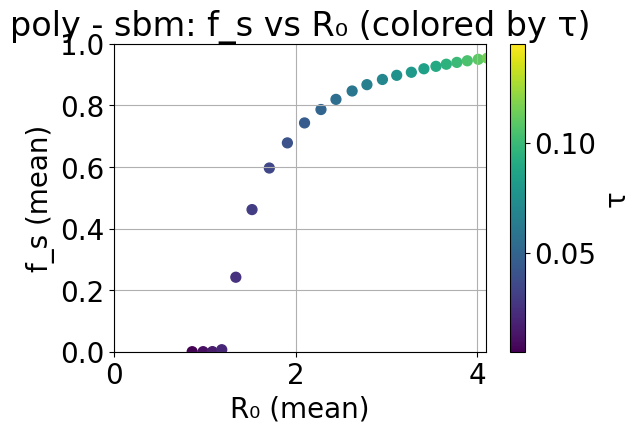

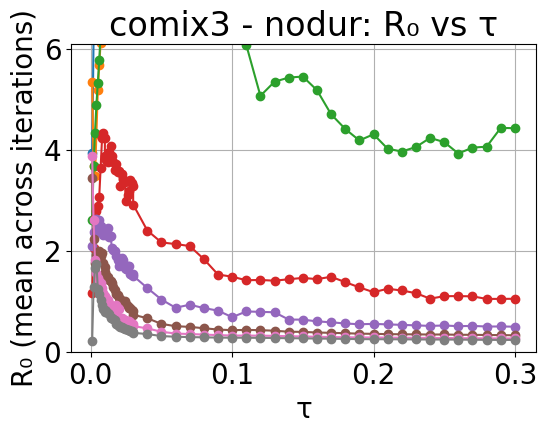

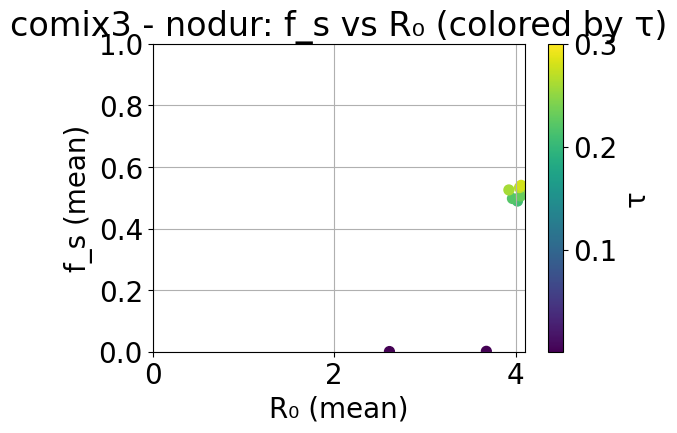

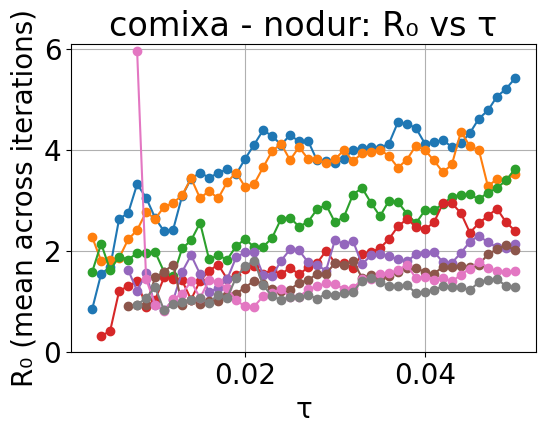

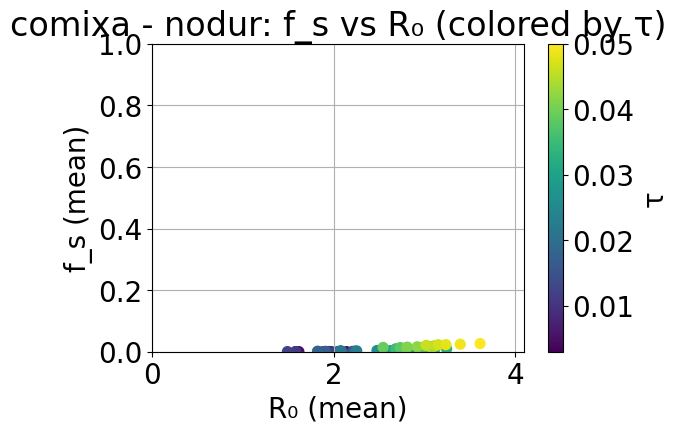

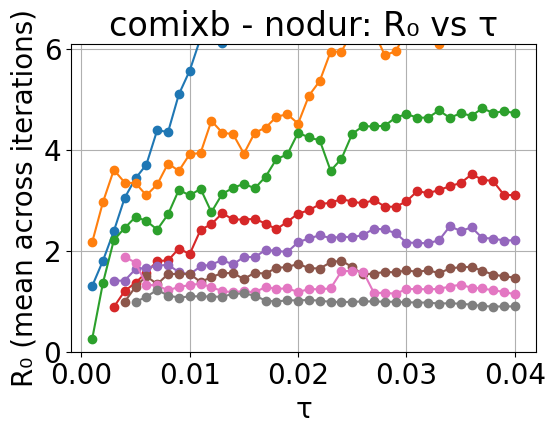

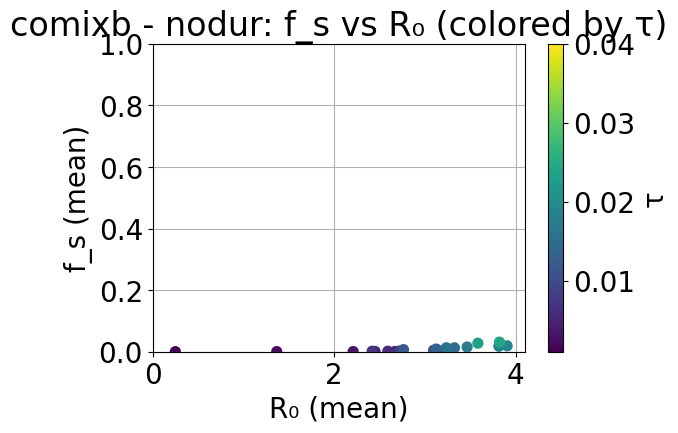

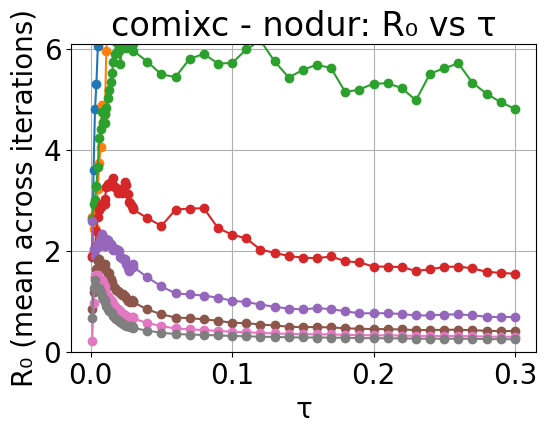

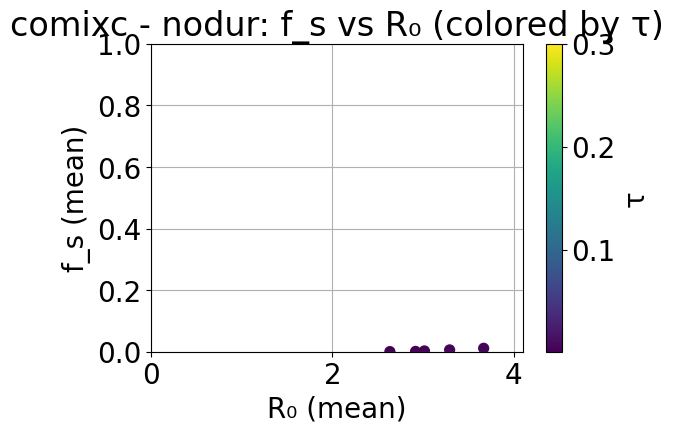

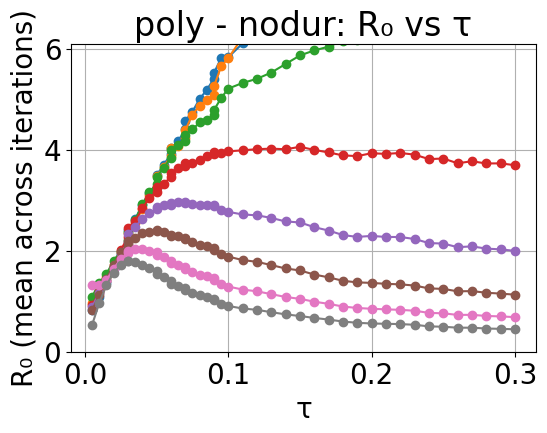

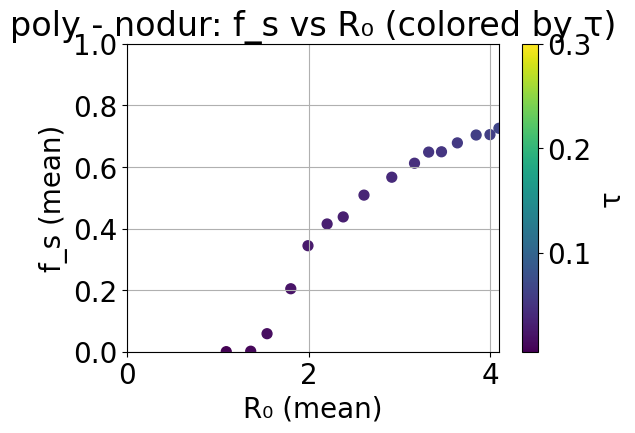

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict
from scipy import stats

datas = ['comix3','comixa','comixb','comixc','poly']
n=100_000

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-5 mins', '5-15 mins', '15-60 mins', '1-4 hours', '4+ hours']

compare = {}
num_network = 40
for model_idx, model in enumerate(['sbm', 'nodur']):
    for data in datas:
        res = {'taus': [], 'fs': [], 'r0': [], 'r02': [], 'r03': [], 'r04': [], 'r05': [], 'r06': [], 'r07': [], 'r08': []}
        for k in range(num_network):
            try:
                with open(f'seir_sims/{data}_{k}_{model}.json', 'r') as f:
                    res_tmp = json.load(f)

                for tau, fs_row, r0_row, r02_row, r03_row, r04_row, r05_row, r06_row, r07_row, r08_row in zip(res_tmp["taus"], res_tmp["fs"], res_tmp["r0"], res_tmp['r02'], res_tmp['r03'], res_tmp['r04'], res_tmp['r05'], res_tmp['r06'], res_tmp['r07'], res_tmp['r08']):
                    if tau not in res["taus"]:
                        res["taus"].append(tau)
                        res["fs"].append(fs_row)
                        res["r0"].append(r0_row)
                        res["r02"].append(r02_row)
                        res["r03"].append(r03_row)
                        res["r04"].append(r04_row)
                        res["r05"].append(r05_row)
                        res["r06"].append(r06_row)
                        res["r07"].append(r07_row)
                        res["r08"].append(r08_row)
                    else:
                        idx = res["taus"].index(tau)
                        for fs, r0, r02, r03, r04, r05, r06, r07, r08 in zip(fs_row, r0_row, r02_row, r03_row, r04_row, r05_row, r06_row, r07_row, r08_row):
                            res["fs"][idx].append(fs)
                            res["r0"][idx].append(r0)
                            res["r02"][idx].append(r02)
                            res["r03"][idx].append(r03)
                            res["r04"][idx].append(r04)
                            res["r05"][idx].append(r05)
                            res["r06"][idx].append(r06)
                            res["r07"][idx].append(r07)
                            res["r08"][idx].append(r08)
            except:
                a=1
                
        taus = res["taus"]
        r0 = res["r0"]          
        r02 = res["r02"]           
        r03 = res["r03"] 
        r04 = res["r04"]
        r05 = res["r05"]
        r06 = res["r06"]
        r07 = res["r07"]
        r08 = res["r08"]         
        fs = res['fs']
        
        sorted_data = sorted(zip(taus, fs, r0, r02, r03, r04, r05, r06, r07, r08), key=lambda x: x[0])
        taus, fs, r0, r02, r03, r04, r05, r06, r07, r08 = map(list, zip(*sorted_data))

        r0_mean = [np.mean([b for b in a if b>0]) for a in r0]
        r02_mean = [np.mean([b for b in a if b>0]) for a in r02]
        r03_mean = [np.mean([b for b in a if b>0]) for a in r03]
        r04_mean = [np.mean([b for b in a if b>0]) for a in r04]
        r05_mean = [np.mean([b for b in a if b>0]) for a in r05]
        r06_mean = [np.mean([b for b in a if b>0]) for a in r06]
        r07_mean = [np.mean([b for b in a if b>0]) for a in r07]
        r08_mean = [np.mean([b for b in a if b>0]) for a in r08]
        fs_mean = [np.mean([b for b in a if b>0]) for a in fs]
        
        # R0 vs taus
        r0_mean = [a if idx in [0,len(r0_mean)] else np.mean(r0_mean[idx-1:idx+2]) for idx, a in enumerate(r0_mean)]
        r02_mean = [a if idx in [0,len(r02_mean)] else np.mean(r02_mean[idx-1:idx+2]) for idx, a in enumerate(r02_mean)]
        r03_mean = [a if idx in [0,len(r03_mean)] else np.mean(r03_mean[idx-1:idx+2]) for idx, a in enumerate(r03_mean)]
        r04_mean = [a if idx in [0,len(r04_mean)] else np.mean(r04_mean[idx-1:idx+2]) for idx, a in enumerate(r04_mean)]
        r05_mean = [a if idx in [0,len(r05_mean)] else np.mean(r05_mean[idx-1:idx+2]) for idx, a in enumerate(r05_mean)]
        r06_mean = [a if idx in [0,len(r06_mean)] else np.mean(r06_mean[idx-1:idx+2]) for idx, a in enumerate(r06_mean)]
        r07_mean = [a if idx in [0,len(r07_mean)] else np.mean(r07_mean[idx-1:idx+2]) for idx, a in enumerate(r07_mean)]
        r08_mean = [a if idx in [0,len(r08_mean)] else np.mean(r08_mean[idx-1:idx+2]) for idx, a in enumerate(r08_mean)]
        plt.figure(figsize=(6,4))
        plt.plot(taus, r0_mean, marker='o', label="R₀ 1")
        plt.plot(taus, r02_mean, marker='o', label="R₀ 2")
        plt.plot(taus, r03_mean, marker='o', label="R₀ 3")
        plt.plot(taus, r04_mean, marker='o', label="R₀ 4")
        plt.plot(taus, r05_mean, marker='o', label="R₀ 5")
        plt.plot(taus, r06_mean, marker='o', label="R₀ 6")
        plt.plot(taus, r07_mean, marker='o', label="R₀ 7")
        plt.plot(taus, r08_mean, marker='o', label="R₀ 8")
        

        plt.xlabel("τ")
        plt.ylabel("R₀ (mean across iterations)")
        plt.title(f"{data} - {model}: R₀ vs τ")
        plt.ylim(0, 6.1)
        # plt.legend()
        plt.grid(True)
        # plt.savefig(f'figs/sim_out/{data}_tau_vs_r0.png')
        plt.show()

        # Fs vs R0
        plt.figure(figsize=(6,4))
        plt.scatter(r03_mean, fs_mean, c=taus, cmap="viridis", s=50)
        plt.colorbar(label="τ")
        plt.xlabel("R₀ (mean)")
        plt.ylabel("f_s (mean)")
        plt.title(f"{data} - {model}: f_s vs R₀ (colored by τ)")
        plt.xlim(0, 4.1)
        plt.ylim(0, 1)
        plt.grid(True)
        # plt.savefig(f'figs/sim_out/{data}_fs_vs_r0.png')
        plt.show()

        r0_mean = [[b for b in a if b>0] for a in r0 if len(a) > 5]
        r02_mean = [[b for b in a if b>0] for a in r02 if len(a) > 5]
        r03_mean = [[b for b in a if b>0] for a in r03 if len(a) > 5]
        fs_mean = [[b for b in a if b>0] for a in fs if len(a) > 5]
        taus = [a for i, a in enumerate(taus) if len(r0[i]) > 5]
        compare[data] = (taus, r0_mean, r02_mean, r03_mean, fs_mean)
        

    with open(f'seir_sims/together/fs_{model}.json', 'w') as f:
        json.dump(compare, f)

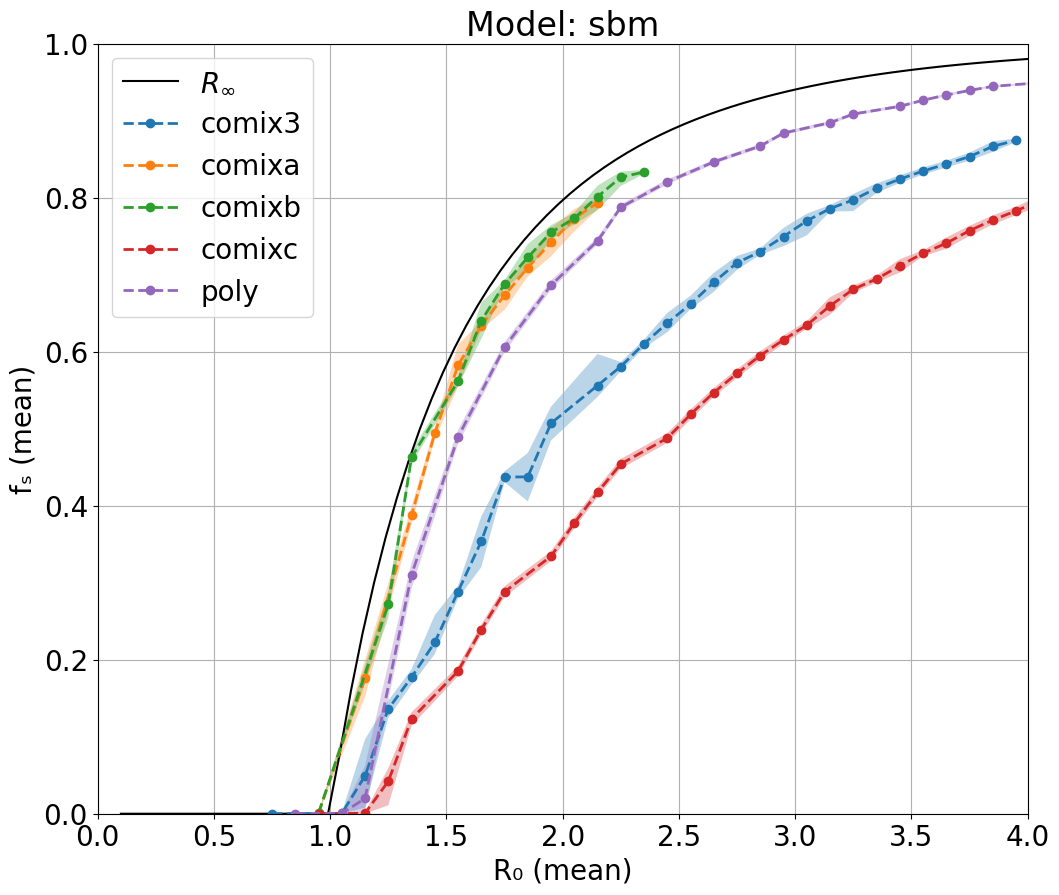

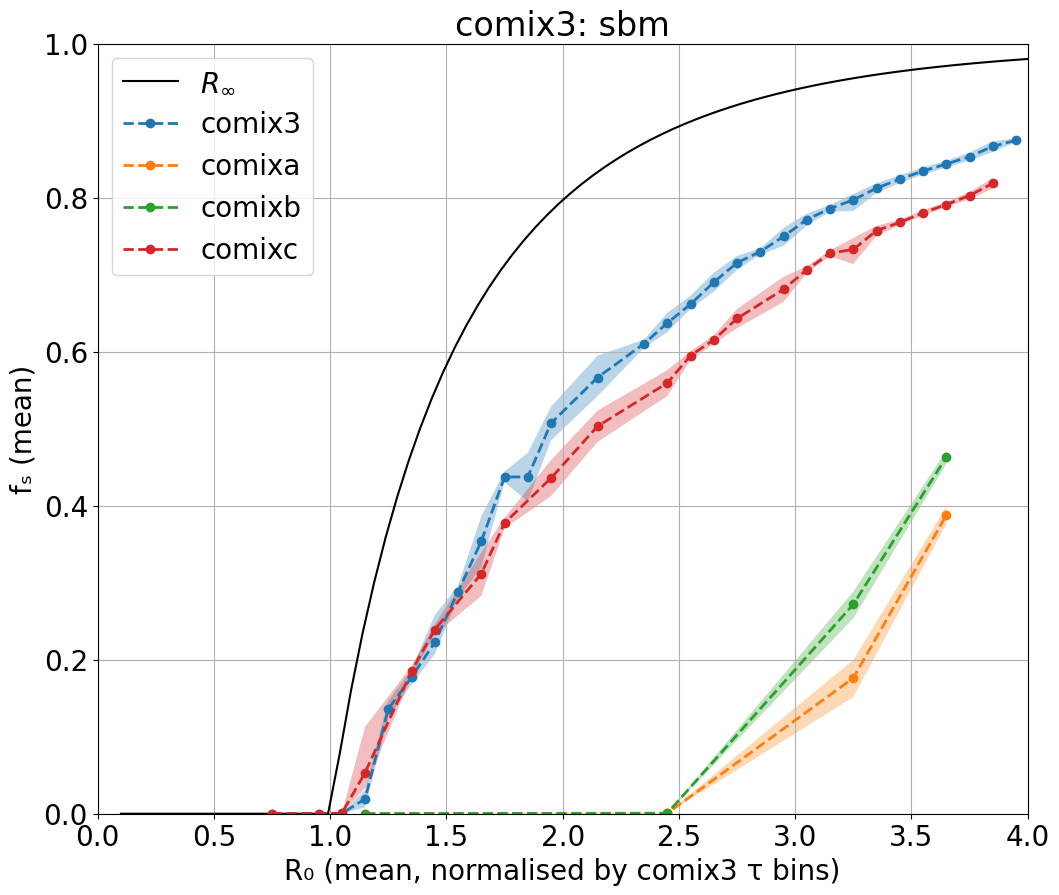

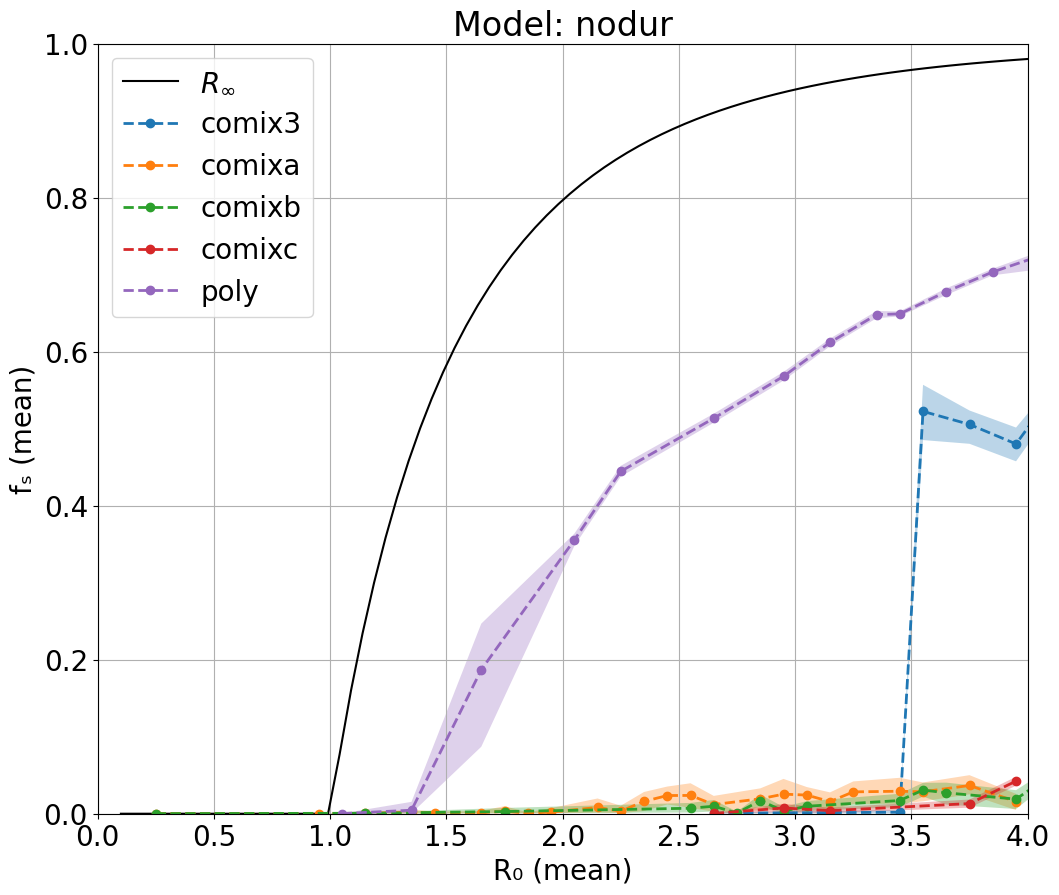

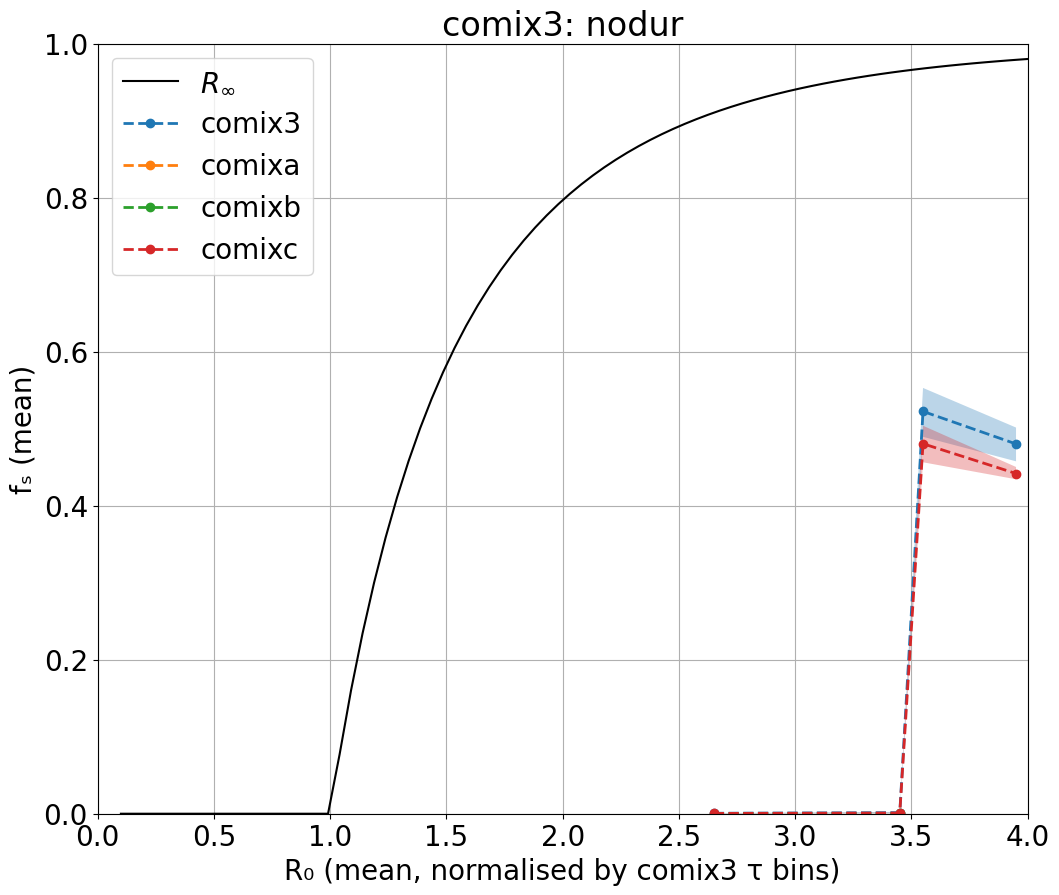

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.optimize import fsolve
from scipy import stats

def final_size(R0):
    func = lambda Z: Z - (1 - np.exp(-R0 * Z))
    Z0_guess = 0.5
    Z_solution, = fsolve(func, Z0_guess)
    return Z_solution

def final_size_array(R0_array):
    return np.array([final_size(R0) for R0 in R0_array])
R0_vals = np.linspace(0.1, 5, 100)
Z_vals = final_size_array(R0_vals)

bin_edges = np.arange(0, 4.2, 0.1) 
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

for model in ['sbm', 'nodur']:
    plt.figure(figsize=(12,10))
    plt.plot(R0_vals, Z_vals, 'k', label=r'$R_\infty$')
    with open(f'seir_sims/together/fs_{model}.json', 'r') as f:
        compare = json.load(f)

    for key in compare.keys():
        fs_vals = [[] for _ in bin_centers]
        taus, r0, r02, r03, fs = compare[key]
        r03_mean = [np.mean([b for b in a if b>0]) if len(a) > 0 else np.nan for a in r03]
        
        for tau_idx, tau_sim in enumerate([a for a in r03]):
            if len(tau_sim) > 0:
                for val_idx, _ in enumerate(tau_sim):
                    for bin_idx in range(len(bin_edges) - 1):
                        if bin_edges[bin_idx] <= r03_mean[tau_idx] < bin_edges[bin_idx + 1]:
                            fs_vals[bin_idx].append(fs[tau_idx][val_idx])
                            break
        fs_mean = [np.mean(a) if len(a) > 0 else np.nan for a in fs_vals]
        ## remove what did not take off
        fs_vals = [[b for b in a if b > fs_mean[idx]/3] for idx, a in enumerate(fs_vals)]
        fs_mean = [np.mean(a) if len(a) > 0 else np.nan for a in fs_vals]
        ci_lower = [np.percentile(a, 5) if len(a) > 0 else np.nan for a in fs_vals]
        ci_upper = [np.percentile(a, 95) if len(a) > 0 else np.nan for a in fs_vals]
        
        bin_centers_tmp = bin_centers[~np.isnan(fs_mean)]
        fs_mean = np.array(fs_mean)[~np.isnan(fs_mean)]
        ci_lower = np.array(ci_lower)[~np.isnan(ci_lower)]
        ci_upper = np.array(ci_upper)[~np.isnan(ci_upper)]

        plt.plot(bin_centers_tmp, fs_mean, 'o--', label=key, linewidth=2)
        plt.fill_between(bin_centers_tmp, ci_lower, ci_upper, alpha=0.3)
    plt.title(f'Model: {model}')
    plt.xlabel("R₀ (mean)")
    plt.ylabel("fₛ (mean)")
    plt.xlim(0, 4)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


    ## use c3 as reference
    # ref_keys = ['comix3', 'comixa', 'comixb', 'comixc']
    ref_keys = ['comix3']
    for ref_key in ref_keys:
        taus_ref, r0_ref, r02_ref, r03_ref, fs_ref = compare[ref_key]
        r03_mean_ref = [np.mean([b for b in a if b > 0]) for a in r03_ref if len(a) > 0]

        tau_bins = []
        for bc in bin_centers:
            idxs = [i for i, val in enumerate(r03_mean_ref)
                    if bin_edges[np.argmin(np.abs(bin_centers - bc))] <= val < bin_edges[np.argmin(np.abs(bin_centers - bc)) + 1]]
            if len(idxs) > 0:
                tau_range = [np.min(np.array(taus_ref)[idxs]), np.max(np.array(taus_ref)[idxs])]
            else:
                tau_range = [np.nan, np.nan]
            tau_bins.append(tau_range)
            
        plt.figure(figsize=(12,10))
        plt.plot(R0_vals, Z_vals, 'k', label=r'$R_\infty$')

        for key in compare.keys():
            if key == 'poly':
                continue
            taus, r0, r02, r03, fs = compare[key]
            fs_vals = [[] for _ in bin_centers]

            for tau_idx, tau_sim in enumerate([a for a in r03 if len(a) > 0]):
                tau_value = taus[tau_idx]
                for bin_idx, tau_range in enumerate(tau_bins):
                    if np.isnan(tau_range[0]): 
                        continue
                    if tau_range[0] <= tau_value <= tau_range[1]:
                        fs_vals[bin_idx].extend(fs[tau_idx])
                        break

            fs_mean = [np.mean(a) if len(a) > 0 else np.nan for a in fs_vals]
            fs_vals = [[b for b in a if b > fs_mean[idx]/2 and b < fs_mean[idx]*2] for idx, a in enumerate(fs_vals)]
            fs_mean = [np.mean(a) if len(a) > 0 else np.nan for a in fs_vals]
            ci_lower = [np.percentile(a, 5) if len(a) > 0 else np.nan for a in fs_vals]
            ci_upper = [np.percentile(a, 95) if len(a) > 0 else np.nan for a in fs_vals]

            bin_centers_tmp = bin_centers[~np.isnan(fs_mean)]
            fs_mean = np.array(fs_mean)[~np.isnan(fs_mean)]
            ci_lower = np.array(ci_lower)[~np.isnan(ci_lower)]
            ci_upper = np.array(ci_upper)[~np.isnan(ci_upper)]

            plt.plot(bin_centers_tmp, fs_mean, 'o--', label=key, linewidth=2)
            plt.fill_between(bin_centers_tmp, ci_lower, ci_upper, alpha=0.3)

        plt.title(f'{ref_key}: {model}')
        plt.xlabel("R₀ (mean, normalised by comix3 τ bins)")
        plt.ylabel("fₛ (mean)")
        plt.xlim(0, 4)
        plt.ylim(0, 1)
        plt.grid(True)
        plt.legend()
        plt.show()
        

# Secondary Case distribution plots

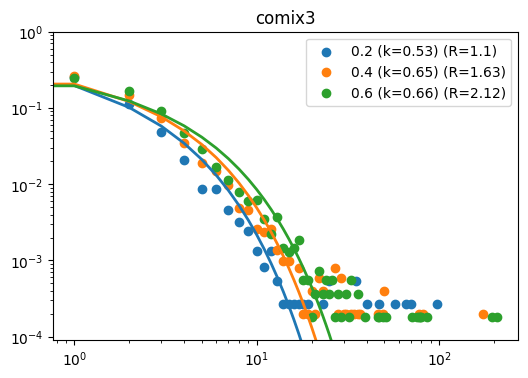

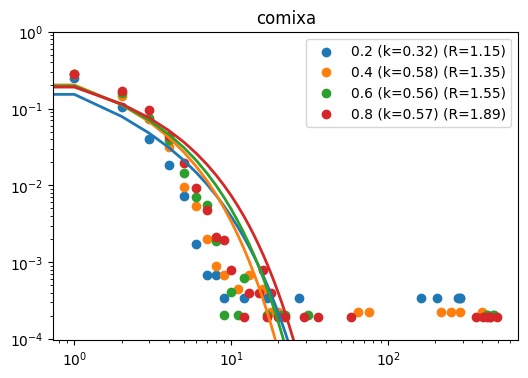

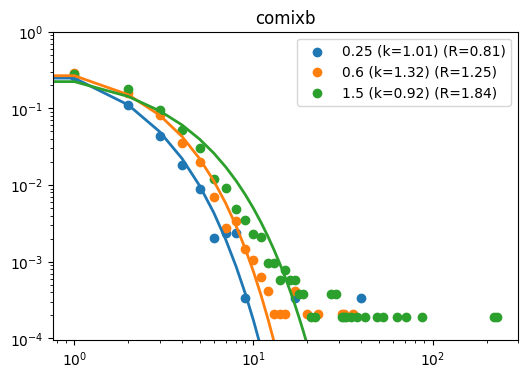

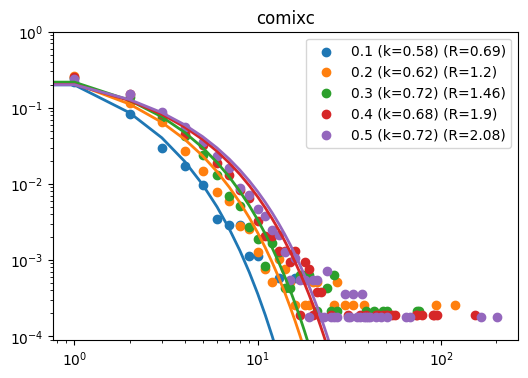

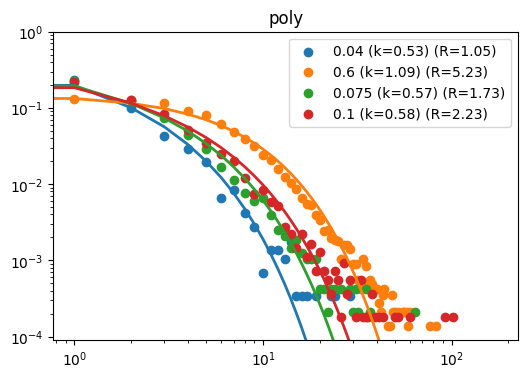

In [60]:
## secondary case distributions

import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict
from scipy import stats
from itertools import chain
from scipy.optimize import minimize
from scipy.stats import nbinom

datas = ['comix3','comixa','comixb','comixc','poly']
n=100_000

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-5 mins', '5-15 mins', '15-60 mins', '1-4 hours', '4+ hours']

def fit_negative_binomial(sc):
    """Fit a Negative Binomial to count data and return (k, p)."""
    sc = np.array(sc)
    mean = np.mean(sc)
    var = np.var(sc, ddof=1)
    
    # Use method-of-moments as starting values
    k_init = mean**2 / (var - mean) if var > mean else 10
    p_init = k_init / (k_init + mean)
    
    # Define the negative log-likelihood
    def neg_log_likelihood(params):
        k, p = params
        if k <= 0 or not (0 < p < 1):
            return np.inf
        return -np.sum(nbinom.logpmf(sc, k, p))
    
    res = minimize(neg_log_likelihood, x0=[k_init, p_init],
                   bounds=[(1e-6, None), (1e-6, 1-1e-6)])
    
    k_mle, p_mle = res.x
    return k_mle, p_mle

compare = {}
num_network = 20
for data in datas:
    res = {'taus': [], 'sc': [], 'sc2': [], 'sc3': []}
    for k in range(num_network):
        try:
            with open(f'seir_sims/{data}_{k}_sc.json', 'r') as f:
                res_tmp = json.load(f)
            for tau, r0_row, r02_row, r03_row in zip(res_tmp["taus"], res_tmp["sc"], res_tmp['sc2'], res_tmp['sc3']):
                if isinstance(r0_row[0], list):
                    r0_row = list(chain.from_iterable(r0_row))
                if isinstance(r02_row[0], list):
                    r02_row = list(chain.from_iterable(r02_row))
                if isinstance(r03_row[0], list):
                    r03_row = list(chain.from_iterable(r03_row))
                if tau not in res["taus"]:
                    res["taus"].append(tau)
                    res["sc"].append(r0_row)
                    res["sc2"].append(r02_row)
                    res["sc3"].append(r03_row)
                else:
                    idx = res["taus"].index(tau)
                    for sc, sc2, sc3 in zip(r0_row, r02_row, r03_row):
                        res["sc"][idx].append(sc)
                        res["sc2"][idx].append(sc2)
                        res["sc3"][idx].append(sc3)
        except:
            a=1
            
    taus = res["taus"]
    sc1 = res["sc"]          
    sc2 = res["sc2"]           
    sc3 = res["sc3"]     
    
    plt.figure(figsize=(6,4))

    for idx, sc in enumerate(sc3):
        k_mle, p_mle = fit_negative_binomial(sc)
        mu_mle = k_mle * (1 - p_mle) / p_mle

        # print(f"MLE estimate for k (dispersion): {k_mle:.3f}")
        # print(f"p = {p_mle:.3f}, loc = {loc_mle}")
        x = np.arange(0, max(sc)+1)
        pmf = nbinom.pmf(x, k_mle, p_mle)
        plt.plot(x, pmf, lw=2)
        y,x = np.histogram(sc, bins=range(0, max(sc)+2), density=True)
        plt.scatter(x[:-1], y, label=f'{taus[idx]} (k={k_mle:.2f}) (R={np.round(np.mean(sc),2)})')
    plt.title(f"{data}")
    plt.yscale('log')
    plt.xscale('log')
    plt.ylim(min(y[y > 0])/2, 1)
    plt.legend()
    plt.show()

### Look at networks small example

make small network example, see whats happening 
compare number of each type of connection in data, gmm and model
make seir possibly?

0.2


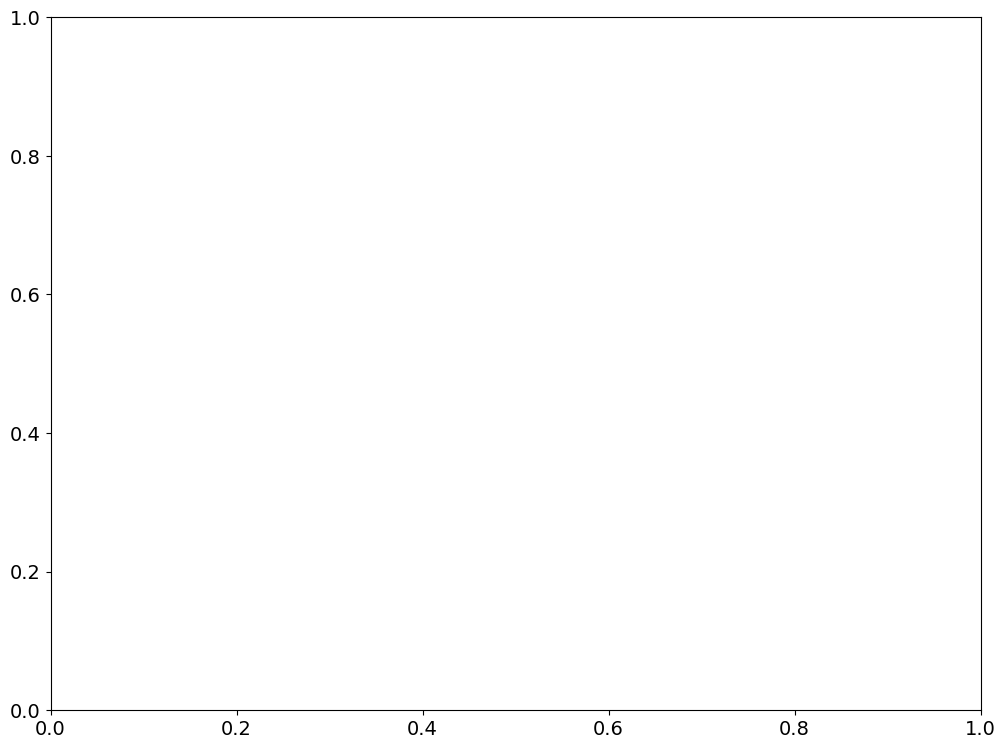

In [26]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import nd_python_avon as nd_p 
import numpy as np
import json
import sklearn.mixture
import math
import matplotlib.pyplot as plt

n = 100_000

taus = [0.2]


buckets = np.array([5,12,18,30,40,50,60,70])
partitions = [0.058*n, 0.145*n, 0.212*n, 0.364*n, 0.497*n, 0.623*n, 0.759*n, 0.866*n, n]

per_partition = [a if i == 0 else a-partitions[i-1] for i, a in enumerate(partitions)]

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-1 hour', '1-4 hours', '4+ hours']
datas = ['comix3']


for i, data in enumerate(datas):
    with open(f'data/gmm_opt_comp/optimal_components_{data}_log_smalldur.json', 'r') as f:
        optimal_num_components = json.load(f)
    ##################### read fits ####################################
    with open(f'../input_data/egos/{data}_dur_small.json', 'r') as f:
        egos = json.load(f)
    props = np.genfromtxt(f'../input_data/durations/{data}.csv', delimiter=',')
    
    samples_for_plot = []
    classifier = []
    samples = []
    for l, _ in enumerate(partitions):
        samples_for_plot.append([])
        classifier.append(sklearn.mixture.GaussianMixture(n_components=optimal_num_components[data][l], covariance_type='full'))
        egos_age = [a for a in egos if a['age'] == l]
        ## use log(k+1) instead of k to fit
        X = [[math.log(b+1) for b in a['contacts']] for a in egos_age]
        classifier[l].fit(X)
        ## sample same number of people as the data
        samples_tmp,_ = classifier[l].sample(per_partition[l])
        for sample in samples_tmp:
            samples.append([int(np.round(np.exp(b)-1)) if int(np.round(np.exp(b)-1))>=0 else 0 for b in sample])
            samples_for_plot[-1].append([int(np.round(np.exp(b)-1)) if int(np.round(np.exp(b)-1))>=0 else 0 for b in sample])
    fig1, ax1 = plt.subplots(1,1, figsize=(12,9))
    for tau in taus:
        print(tau)
        res = nd_p.small_dur_gillesp(samples,partitions=partitions,num_dur=3, tau=tau,props=props.tolist(),num_infec=5)
        with open(f'networks/small_{data}_{tau}.json','w') as f:
            json.dump(res, f)

    #     infecs, cur = [], 0
    #     for val in res['i_events']:
    #         cur = cur+1 if val >= 0 else cur-1
    #         infecs.append(cur)
    #     ax1.plot(res['ts'], infecs, label=f'tau={tau}')
    #     ax1.set_xlabel('Time')
    #     ax1.set_ylabel('Number of Infectious Individuals')

    #     fig2, ax2 = plt.subplots(2,3, figsize=(12,9))
    #     for j in range(6):
    #         cur_gen = [idx for idx,b in enumerate(res['generation']) if b==j+1]
    #         contacts_per_duration = np.zeros((len(cur_gen), 5))
    #         sc_per_duration = np.zeros((len(cur_gen), 5))
    #         for idx, person in enumerate(cur_gen):
    #             for contact in res['adjacency_matrix'][person]:
    #                 contacts_per_duration[idx][contact[-1]] += 1
    #                 if res['disease_from'][contact[1]] == person:
    #                     sc_per_duration[idx][contact[-1]] += 1
    #         normal_cpd, normal_scpd = np.copy(contacts_per_duration), np.copy(sc_per_duration)
    #         for idx, person_c, person_sc in enumerate(zip(contacts_per_duration, sc_per_duration)):
    #             if sum(person_c) == 0:
    #                 contacts_per_duration[idx] / sum(person_c)
    #             if sum(person_sc) == 0:
    #                 sc_per_duration[idx] / sum(person_sc)
    #         x = np.arange(len(cur_gen))
    #         colors = plt.cm.viridis(np.linspace(0.2, 0.8, 5))
    #         bottom = np.zeros(len(cur_gen))
    #         for idx in range(5):
    #             # print(normal_cpd.shape, bottom.shape)
    #             ax2[j//3][j%3].bar(x, normal_cpd[:, idx], bottom=bottom, color=colors[idx], edgecolor="black")
    #             bottom += normal_cpd[:, idx]
    #         sums = contacts_per_duration.sum(axis=1)
    #         for idx, s in enumerate(sums):
    #             ax2[j//3][j%3].text(idx, s + 0.02, f"{s:.2f}", ha="center", va="bottom", fontsize=9)
                
    #         for idx in range(5):
    #             ax2[j//3][j%3].bar(x, bottom, bottom=normal_scpd[:,idx], color=colors[idx], edgecolor="black")
    #             bottom -= normal_scpd[:, idx]
    #         sums = sc_per_duration.sum(axis=1)
    #         for idx, s in enumerate(sums):
    #             ax2[j//3][j%3].text(idx, s + 0.02, f"{s:.2f}", ha="center", va="bottom", fontsize=9)
    #         ax2[j//3][j%3].set_ylabel("Contact durations")
    #         ax2[j//3][j%3].set_xlabel("Index")
    #         ax2[j//3][j%3].set_xticklabels(cur_gen)
    #         ax2[j//3][j%3].set_title(f"Generation {j+1}")
    #         ax2[j//3][j%3].set_ylim(0, 1.1)
    #         # ax2[j//3][j%3].set_xticks(x)

    # ax1.legend()
    # plt.show()

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58}


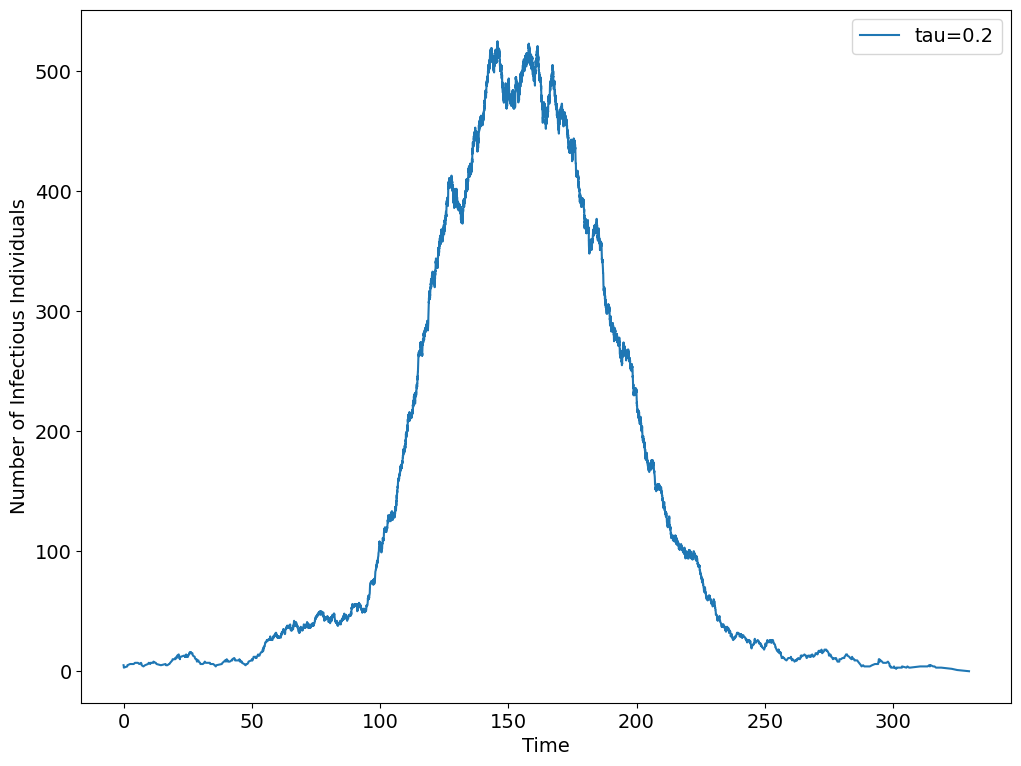

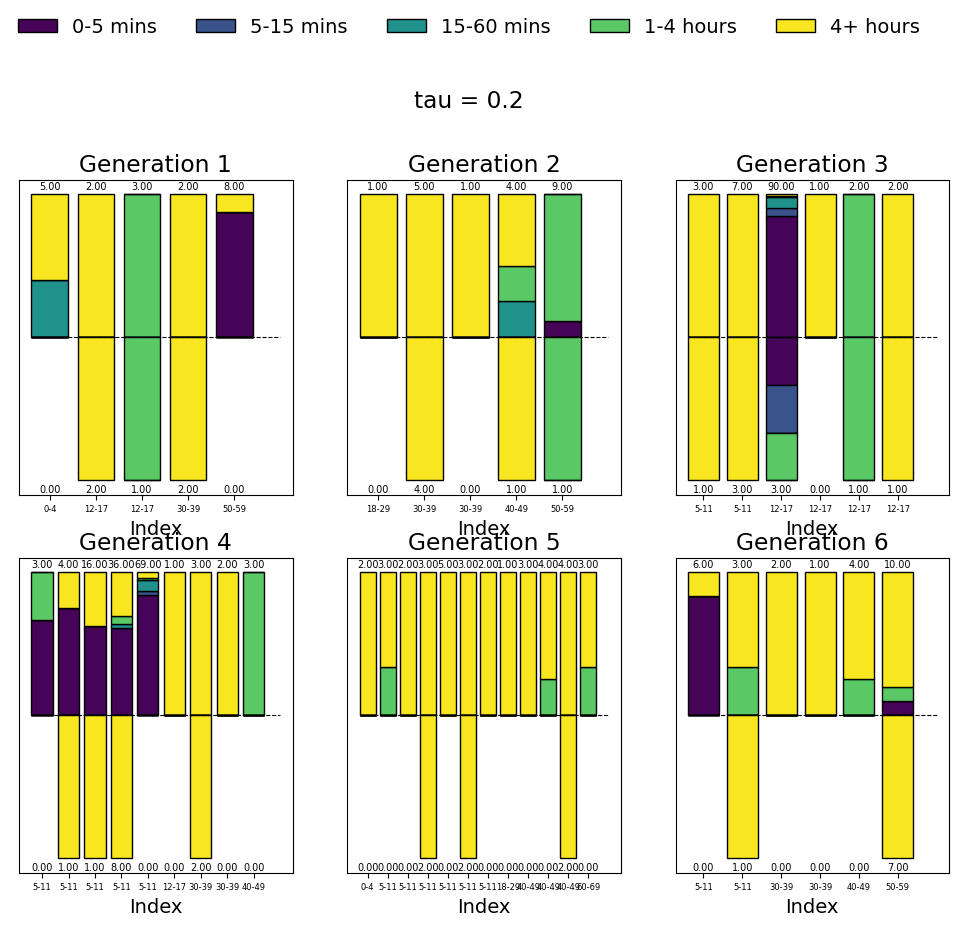

In [27]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import nd_python_avon as nd_p 
import numpy as np
import json
import sklearn.mixture
import math
import matplotlib.pyplot as plt

n = 100_000

taus = [.2]


buckets = np.array([5,12,18,30,40,50,60,70])
partitions = [0.058*n, 0.145*n, 0.212*n, 0.364*n, 0.497*n, 0.623*n, 0.759*n, 0.866*n, n]

per_partition = [a if i == 0 else a-partitions[i-1] for i, a in enumerate(partitions)]

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-5 mins', '5-15 mins', '15-60 mins', '1-4 hours', '4+ hours']
dur_label = ['5','15', '60', '2', '4']
datas = ['comix3']


for i, data in enumerate(datas):
    with open(f'../input_data/egos/{data}_dur_small.json', 'r') as f:
        egos = json.load(f)
    fig1, ax1 = plt.subplots(1,1, figsize=(12,9))
    for tau in taus:
        # res = nd_p.small_dur_gillesp(samples,partitions=partitions,num_dur=3, tau=tau,props=props.tolist())
        # with open(f'networks/small_{data}_{tau}.json','w') as f:
        #     json.dump(res, f)
        with open(f'networks/small_{data}_{tau}.json','r') as f:
            res = json.load(f)
        infecs = [a[2] for a in res['sir']]        
        ax1.plot(res['ts'][4:], infecs, label=f'tau={tau}')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Number of Infectious Individuals')

        fig2, ax2 = plt.subplots(2,3, figsize=(12,9))
        print(set(res['generation']))
        for j in range(6):
            cur_gen = [idx for idx,b in enumerate(res['generation']) if b==j+1]
            contacts_per_duration = np.zeros((len(cur_gen), 5))
            sc_per_duration = np.zeros((len(cur_gen), 5))
            for idx, person in enumerate(cur_gen):
                for contact in res['adjacency_matrix'][person]:
                    contacts_per_duration[idx][contact[-1]] += 1
                    if res['disease_from'][contact[1]] == person:
                        sc_per_duration[idx][contact[-1]] += 1
            normal_cpd, normal_scpd = np.zeros((len(cur_gen), 5)), np.zeros((len(cur_gen), 5))
            for idx, _ in enumerate(normal_cpd):
                if sum(contacts_per_duration[idx]) != 0:
                    normal_cpd[idx] = contacts_per_duration[idx] / sum(contacts_per_duration[idx])
                if sum(sc_per_duration[idx]) != 0:
                    normal_scpd[idx] = sc_per_duration[idx] / sum(sc_per_duration[idx])
            x = np.arange(len(cur_gen))
            colors = plt.cm.viridis(np.linspace(0.01, .99, 5))
            bottom = np.zeros(len(cur_gen))
            bars = []
            for idx in range(5):
                # print(len(normal_cpd), len(x))
                bar = ax2[j//3][j%3].bar(x, normal_cpd[:, idx], bottom=bottom, color=colors[idx], edgecolor="black")
                bottom += normal_cpd[:, idx]
                bars.append(bar)
            sums = contacts_per_duration.sum(axis=1)
            for idx, s in enumerate(sums):
                ax2[j//3][j%3].text(idx, 1 + 0.02, f"{s:.2f}", ha="center", va="bottom", fontsize=7)
            bottom = np.zeros(len(cur_gen))
            for idx in range(5):
                bottom -= normal_scpd[:, idx]
                ax2[j//3][j%3].bar(x, normal_scpd[:,idx], bottom=bottom, color=colors[idx], edgecolor="black", label=f'{duration_labels[idx]}' if j==0 else '')
            sums = sc_per_duration.sum(axis=1)
            for idx, s in enumerate(sums):
                ax2[j//3][j%3].text(idx, -1 - 0.1, f"{s:.2f}", ha="center", va="bottom", fontsize=7)
            ax2[j//3][j%3].plot([0,len(cur_gen)], [0,0], color='black', linestyle='--', linewidth=0.8)
            ax2[j//3][j%3].set_xlabel("Index")
            ax2[j//3][j%3].set_yticks([])
            ax2[j//3][j%3].set_xticks(x)
            ax2[j//3][j%3].set_xticklabels([bucket_labels[res['ages'][a]] for a in cur_gen], fontsize=6)
            ax2[j//3][j%3].set_title(f"Generation {j+1}")
            ax2[j//3][j%3].set_ylim(-1.1, 1.1)

        fig2.suptitle(f'tau = {tau}')
        fig2.legend(
            handles=[b[0] for b in bars if len(b)>0],  # first rectangle from each stack
            labels=duration_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.08),  # position legend above the figure
            ncol=5,
            frameon=False
        )
    ax1.legend()
    plt.show()

In [28]:
print(len([a for a in res['i_events'] if a>0]), len(res['ts']), len([a for a in res['e_events'] if a>0]), len([a for a in res['r_events'] if a>0]))

6309 18922 6304 6309


In [29]:
from collections import defaultdict

times = defaultdict(list)
for t,a,b,c in zip(res['ts'],res['i_events'], res['e_events'], res['r_events']):
    if a >= 0:
        times[a].append(t)
    if b >= 0:
        times[b].append(t)
    if c >= 0:
        times[c].append(t)

inf, e, rec = [], [], []
keys = list(times.keys())
for key in keys:
    t0 = times[key][0]
    tmp = [a - t0 for a in times[key]]
    if len(tmp) > 2:
        inf.append(t0)
        e.append(tmp[1])
        rec.append(tmp[2])
    else:
        inf.append(t0)
        rec.append(tmp[1])

print(np.mean(e), np.mean(rec))

# plt.figure(figsize=(12,10))
# plt.scatter(list(range(5,len(e)+5)), e, label='Event 1', color='tab:orange', alpha=0.5)
# plt.scatter(list(range(len(rec))), rec, label='Recovery', color='tab:blue', alpha=0.5)
# plt.xticks(list(range(len(rec))), keys)
# plt.xlabel('Person')
# plt.ylabel('Period')
# plt.legend()
# plt.show()

3.0280833855642384 7.030927607771652


In [30]:
infec_times = np.zeros(len(res['degrees']))
for t,i in [(i,a) for i, a in enumerate(res['r_events']) if a >= 0]:
    infec_times[i] += res['ts'][t]
for t,i in [(i,a) for i, a in enumerate(res['i_events']) if a >= 0]:
    infec_times[i] -= res['ts'][t]
    
print(np.mean([a for a in infec_times if a > 0]))
print(1/7)

4.005244034686066
0.14285714285714285
